In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

<xarray.Dataset> Size: 294MB
Dimensions:      (Zmd000002: 2, T: 28, Y: 512, Xp1: 513, Yp1: 513, X: 512,
                  Zld000002: 2)
Coordinates:
  * T            (T) float64 224B 2.16e+04 6.48e+04 ... 1.145e+06 1.188e+06
  * Y            (Y) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
  * Xp1          (Xp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * Yp1          (Yp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * X            (X) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
Dimensions without coordinates: Zmd000002, Zld000002
Data variables:
    diag_levels  (Zmd000002) float64 16B ...
    iter         (T) int32 112B ...
    UVEL         (T, Zmd000002, Y, Xp1) float32 59MB ...
    VVEL         (T, Zmd000002, Yp1, X) float32 59MB ...
    THETA        (T, Zmd000002, Y, X) float32 59MB ...
    WVEL         (T, Zld000002, Y, X) float32 59MB ...
    momVort3     (T, Zmd000002, Yp1, Xp1) float32 59MB ...
Attributes: (12/18)
    MITgcm_version

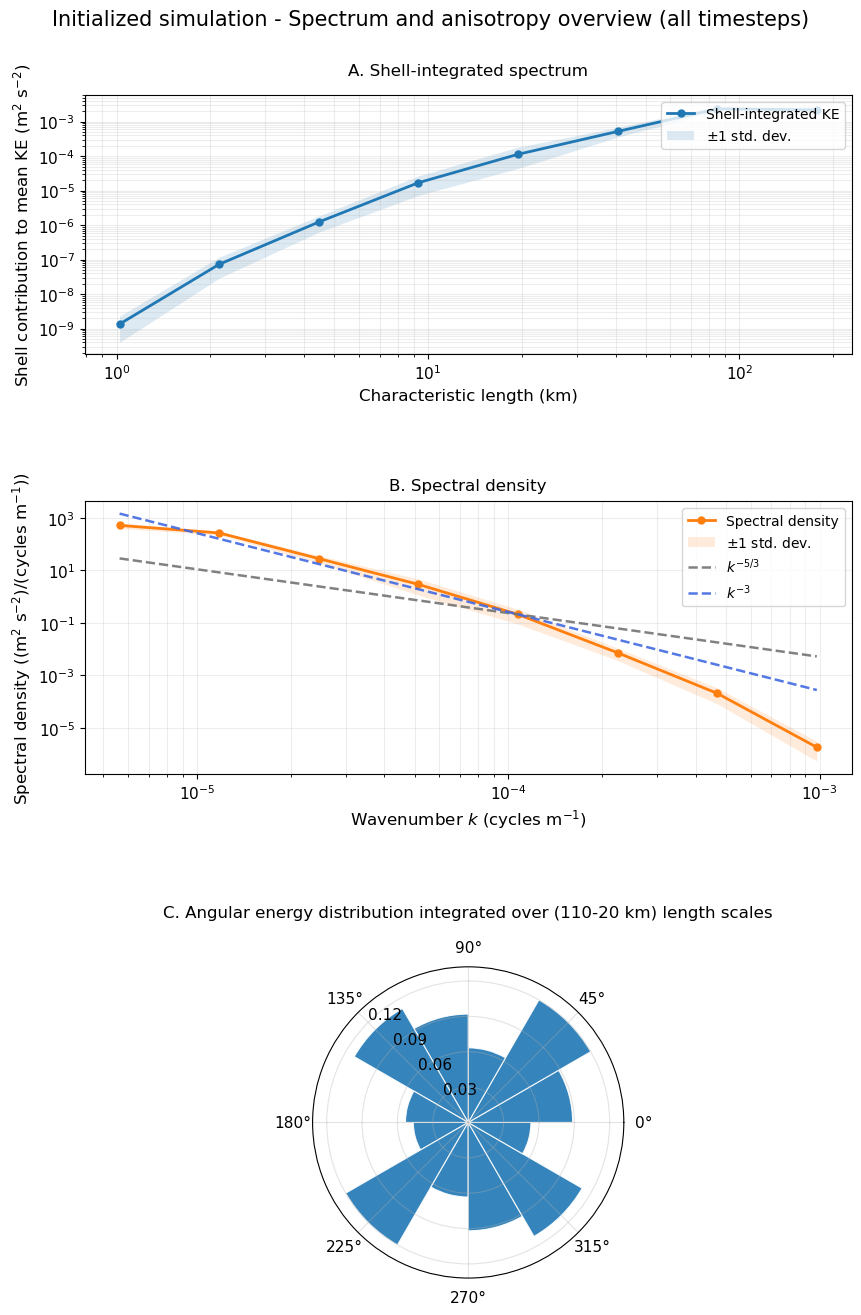

In [2]:
filepath_nc = "../../z.flow_postprocessing/data/input/state_diag.0000000000.glob.nc"

eds_init = oa.calculate_EDS_init(
    filepath_nc,
    target_box=None,
    max_wavelength_km=None,
    x_res=500,
    y_res=500,
    n_bins=8,
    remove_mean=True,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
    snapshot_index=None,
)

snapshot_label = (
    "all timesteps"
    if eds_init.attrs["snapshot_time_index"] is None
    else f"snapshot {eds_init.attrs['snapshot_time_index']})"
)

title = f"Initialized simulation - Spectrum and anisotropy overview ({snapshot_label})"
oa.plot_eds_overview(eds_init, title=title)


c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:461: RuntimeWarning: Mean of empty slice
  window_shell_means.append(np.nanmean(spectra_shell[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:462: RuntimeWarning: Mean of empty slice
  window_density_means.append(np.nanmean(spectra_density[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:463: RuntimeWarning: Mean of empty slice
  window_axis_means.append(np.nanmean(spectra_axis_complex[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:472: RuntimeWarning: Mean of empty slice
  mean_shell = np.nanmean(window_shell_means, axis=0)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Jelle Gortemaker\Documents\T

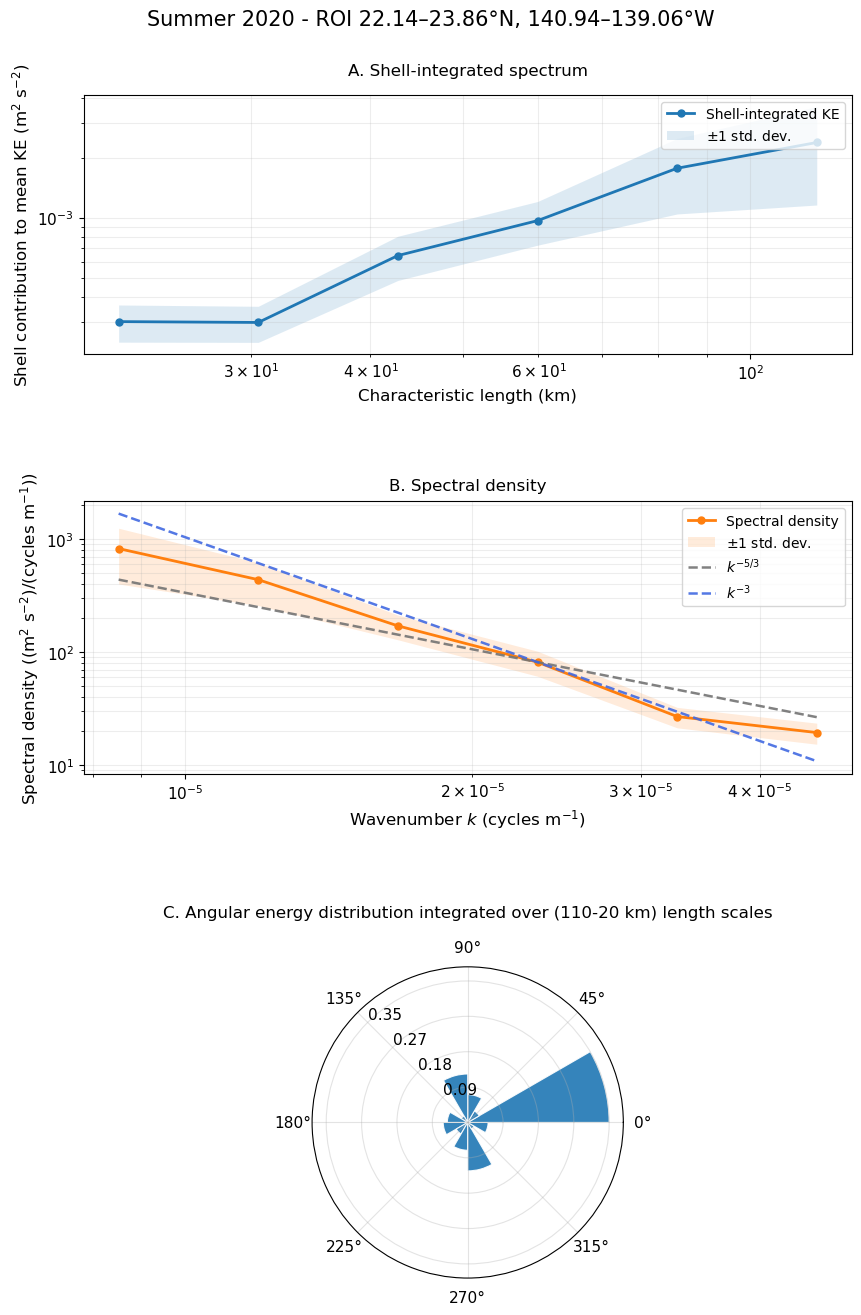

In [3]:
filepath = "../data/GPGP_aug2020.nc"


lat_s, lat_n = 22.14, 23.86
lon_w, lon_e = -140.94, -139.06
# lat_s, lat_n = 20.0, 45.0 # whole GPGP
# lon_w, lon_e = -155.0, -130.0 # whole GPGP

box = [lon_w, lon_e, lat_s, lat_n]


eds = oa.calculate_EDS(
    filepath=filepath,
    target_box=box,
    initialized_velocity=False,
    max_wavelength_km=None,
    n_bins=8,
    remove_mean=True,
    temporal_window_days=1,
    temporal_skip_days=1,
    temporal_stride_days=2,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
)

oa.plot_eds_overview(
    eds,
    title=f"Summer 2020 - ROI {lat_s:.2f}–{lat_n:.2f}°N, {abs(lon_w):.2f}–{abs(lon_e):.2f}°W",
    target_box=box,
)

c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:461: RuntimeWarning: Mean of empty slice
  window_shell_means.append(np.nanmean(spectra_shell[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:462: RuntimeWarning: Mean of empty slice
  window_density_means.append(np.nanmean(spectra_density[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:463: RuntimeWarning: Mean of empty slice
  window_axis_means.append(np.nanmean(spectra_axis_complex[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:472: RuntimeWarning: Mean of empty slice
  mean_shell = np.nanmean(window_shell_means, axis=0)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Jelle Gortemaker\Documents\T

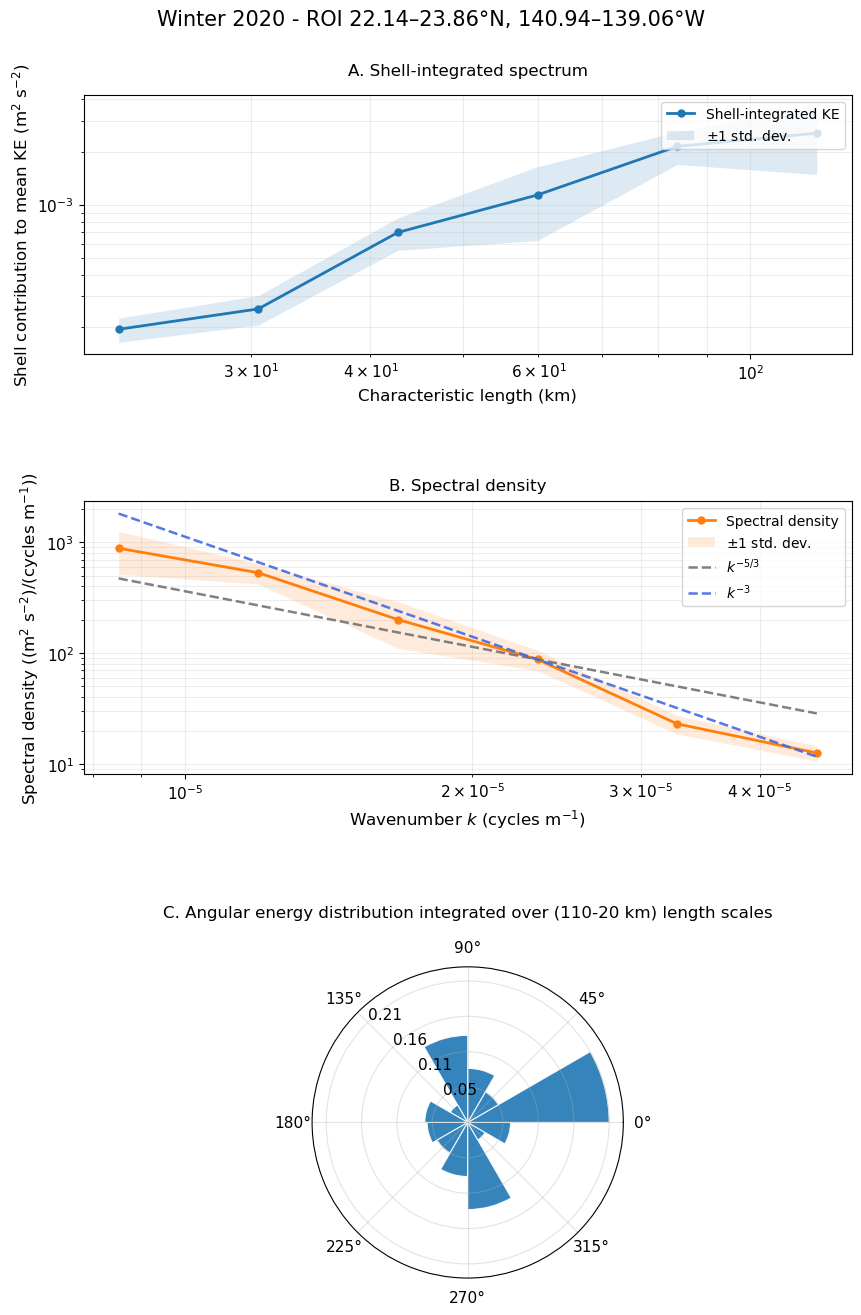

In [4]:
filepath = "../data/GPGP_jan2020.nc"

lat_s, lat_n = 22.14, 23.86
lon_w, lon_e = -140.94, -139.06
# lat_s, lat_n = 20.0, 45.0 # whole GPGP
# lon_w, lon_e = -155.0, -130.0 # whole GPGP

box = [lon_w, lon_e, lat_s, lat_n]


eds = oa.calculate_EDS(
    filepath=filepath,
    target_box=box,
    initialized_velocity=False,
    max_wavelength_km=None,
    n_bins=8,
    remove_mean=True,
    temporal_window_days=1,
    temporal_skip_days=2,
    temporal_stride_days=2,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
)

oa.plot_eds_overview(eds, title=f"Winter 2020 - ROI {lat_s:.2f}–{lat_n:.2f}°N, {abs(lon_w):.2f}–{abs(lon_e):.2f}°W")

c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:461: RuntimeWarning: Mean of empty slice
  window_shell_means.append(np.nanmean(spectra_shell[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:462: RuntimeWarning: Mean of empty slice
  window_density_means.append(np.nanmean(spectra_density[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:463: RuntimeWarning: Mean of empty slice
  window_axis_means.append(np.nanmean(spectra_axis_complex[idx, :], axis=0))
c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts\ocean_analysis.py:472: RuntimeWarning: Mean of empty slice
  mean_shell = np.nanmean(window_shell_means, axis=0)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Jelle Gortemaker\Documents\T

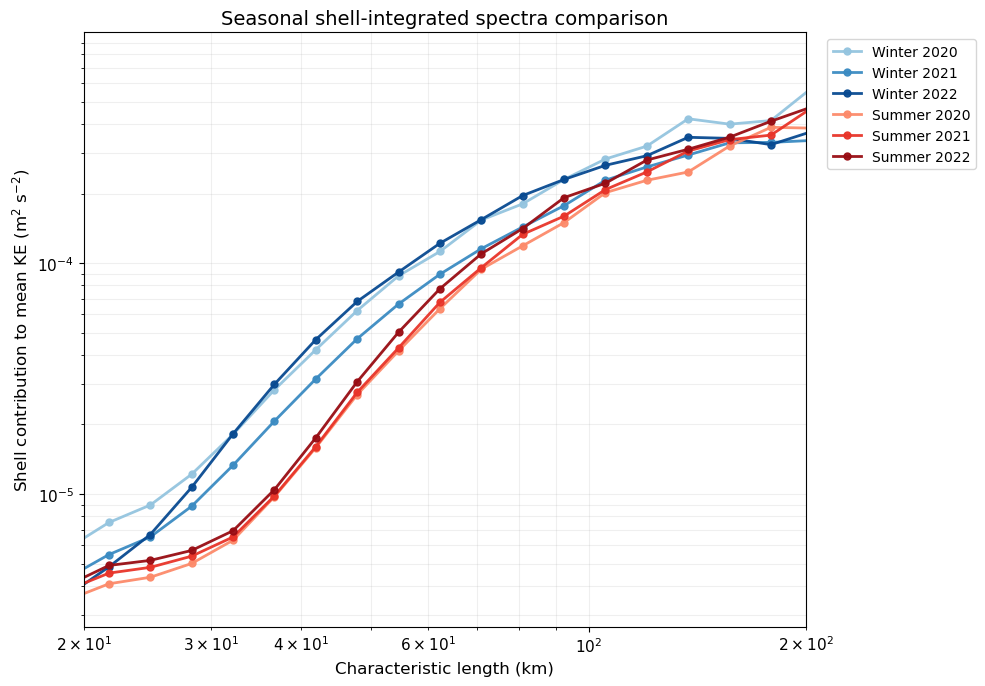

In [5]:
data_groups = {
    "Winter": {
        "2020": "../data/GPGP_jan2020.nc",
        "2021": "../data/GPGP_jan2021.nc",
        "2022": "../data/GPGP_jan2022.nc",
    },
    "Summer": {
        "2020": "../data/GPGP_aug2020.nc",
        "2021": "../data/GPGP_aug2021.nc",
        "2022": "../data/GPGP_aug2022.nc",
    },
}

oa.plot_EDS_seasonal(
    data_groups=data_groups,
    target_box=None,
    initialized_velocity=False,
    max_wavelength_km=None,
    n_bins=40,
    remove_mean=True,
    temporal_window_days=1,
    temporal_skip_days=0,
    temporal_stride_days=1,
    min_modes_per_bin=3,
    spectrum_var="shell_integrated_spectrum",
    title=f"Seasonal shell-integrated spectra comparison",
    xlim_km=(20, 200),
)